# Konfidensintervall og hypotesetest for ett utvalg — Python-beregninger

Denne notatboken inneholder alle Python-beregningene fra beamer-presentasjonen
**«Konfidensintervall og hypotesetesting for ett utvalg»**, i samme rekkefølge
som slidene:

1. Punktestimering
2. Konfidensintervall med $z$-kvantiler og $t$-kvantiler
3. Hypotesetesting: promillekontroll-eksemplet (kritisk verdi, type II-feil, $p$-verdi)
4. Konfidensintervall og hypotesetest for én andel (vraksannsynlighet)
5. Effektstørrelse (Cohens $d$ og $h$)
6. Bootstrap-eksempel med høydedata

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(2026)
plt.rcParams["figure.figsize"] = (6, 3.5)

---
## 1. Punktestimering

**Oppgave:** Tiden $X$ det tar å produsere en vare antas normalfordelt. Produksjonstiden
(i minutter) for 5 tilfeldige enheter er: $42, 37, 39, 44, 38$. Estimer $\mu$, $\sigma^2$ og $\sigma$.

In [2]:
produksjonstid = np.array([42, 37, 39, 44, 38])

mu_hat = produksjonstid.mean()
sigma2_hat = produksjonstid.var(ddof=1)
sigma_hat = produksjonstid.std(ddof=1)

print(f"mu_hat (xbar)     = {mu_hat}")
print(f"sigma2_hat (s^2)  = {sigma2_hat}")
print(f"sigma_hat (s)     = {sigma_hat:.4f}")

mu_hat (xbar)     = 40.0
sigma2_hat (s^2)  = 8.5
sigma_hat (s)     = 2.9155


**Svar:** $\hat\mu=40$, $\hat\sigma^2=8.5$, $\hat\sigma\approx2.9$.

---
## 2. Konfidensintervall

### 2a) Med $z$-kvantiler ($\sigma$ kjent)

**Oppgave:** Kroppshøyde på 5 norske kvinner: $163, 169, 158, 173, 165$ cm.
Standardavviket i populasjonen er kjent, $\sigma=6$ cm. Lag et 95 % og et 90 % KI.

In [3]:
hoyde = np.array([163, 169, 158, 173, 165])
sigma = 6
n = len(hoyde)

xbar = hoyde.mean()
SE = sigma / np.sqrt(n)

for konfidensniva in [0.95, 0.90]:
    alpha = 1 - konfidensniva
    z = stats.norm.ppf(1 - alpha/2)
    ki = (xbar - z*SE, xbar + z*SE)
    print(f"{int(konfidensniva*100)}% KI (z={z:.3f}): "
          f"[{ki[0]:.1f}, {ki[1]:.1f}]  (bredde {ki[1]-ki[0]:.1f})")

95% KI (z=1.960): [160.3, 170.9]  (bredde 10.5)
90% KI (z=1.645): [161.2, 170.0]  (bredde 8.8)


**Svar:** $\bar x=165.6$, $SE=2.68$. $95\,\%$ KI $=[160.3,\,170.9]$ (bredde $10.6$),
$90\,\%$ KI $=[161.2,\,170.0]$ (bredde $8.8$) --- lavere konfidensnivå gir smalere intervall.

### 2b) Med $t$-kvantiler ($\sigma$ ukjent)

**Oppgave:** Samme produksjonstider som i punkt 1: $42, 37, 39, 44, 38$. Denne gangen kjenner
vi *ikke* $\sigma$ --- vi må bruke $S$. Lag et 95 % KI for $\mu$.

In [4]:
S = produksjonstid.std(ddof=1)
n = len(produksjonstid)
df = n - 1

SE = S / np.sqrt(n)
t_star = stats.t.ppf(0.975, df)
ki = (mu_hat - t_star*SE, mu_hat + t_star*SE)

print(f"S = {S:.4f}, SE = {SE:.4f}, df = {df}, t* = {t_star:.4f}")
print(f"95% KI: [{ki[0]:.1f}, {ki[1]:.1f}]")

S = 2.9155, SE = 1.3038, df = 4, t* = 2.7764
95% KI: [36.4, 43.6]


**Svar:** $95\,\%$ KI $=[36.4,\,43.6]$ minutter --- mye bredere enn hvis vi
(feilaktig) hadde brukt $z_{\alpha/2}=1.96$ i stedet for $t_{\alpha/2}=2.776$.

---
## 3. Hypotesetesting: promillekontroll

**Oppgave:** I en promillekontroll skal sjåføren straffes ved over $0.2$ i promille.
Alkometeret registrerer $n=5$ uavhengige promilleverdier, normalfordelt med kjent
standardavvik $\sigma=0.08$.

$$H_0: \mu \le 0.2 \qquad H_1: \mu > 0.2$$

### 3a) Kritisk verdi for $\alpha=0.05$

In [5]:
mu0, sigma, n = 0.2, 0.08, 5
alpha = 0.05

SE = sigma / np.sqrt(n)
z_alpha = stats.norm.ppf(1 - alpha)
k = mu0 + z_alpha * SE

print(f"SE = {SE:.4f}")
print(f"z_alpha = {z_alpha:.4f}")
print(f"Kritisk verdi k = {k:.4f}")

SE = 0.0358
z_alpha = 1.6449
Kritisk verdi k = 0.2588


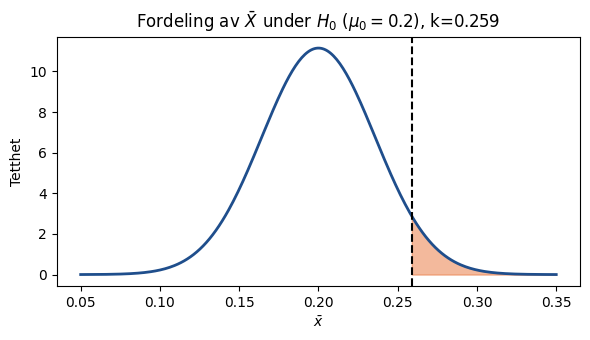

Beslutningsregel: forkast H0 hvis malt gjennomsnitt >= k.
En person som blaser til 0.25 gar fri (0.25 < k).
En person som blaser til 0.30 blir domt (0.30 >= k).


In [6]:
fig, ax = plt.subplots()
x = np.linspace(0.05, 0.35, 300)
ax.plot(x, stats.norm.pdf(x, mu0, SE), color="#1f4e8c", lw=2)
xr = np.linspace(k, 0.35, 100)
ax.fill_between(xr, stats.norm.pdf(xr, mu0, SE), color="#E8743B", alpha=0.5)
ax.axvline(k, color="black", linestyle="--")
ax.set_xlabel(r"$\bar x$")
ax.set_ylabel("Tetthet")
ax.set_title(f"Fordeling av $\\bar X$ under $H_0$ ($\\mu_0=0.2$), k={k:.3f}")
plt.tight_layout()
plt.show()

print("Beslutningsregel: forkast H0 hvis malt gjennomsnitt >= k.")
print("En person som blaser til 0.25 gar fri (0.25 < k).")
print("En person som blaser til 0.30 blir domt (0.30 >= k).")

### 3b) Sannsynlighet for type II-feil (ved $\mu=0.25$)

In [7]:
mu_sann = 0.25
p_type2 = stats.norm.cdf(k, loc=mu_sann, scale=SE)
print(f"P(behold H0 | mu={mu_sann}) = P(Xbar < {k:.4f}) = {p_type2:.4f}")
print(f"Det er ca. {p_type2*100:.0f}% sannsynlig aa gjore en type II-feil.")
Z = (k-0.25)/SE
print('k: ',k)
print('Z: ',Z)
p_type2 = stats.norm.cdf(Z, loc=0, scale=1)#P(Z<0.24731)
print(p_type2)

P(behold H0 | mu=0.25) = P(Xbar < 0.2588) = 0.5977
Det er ca. 60% sannsynlig aa gjore en type II-feil.


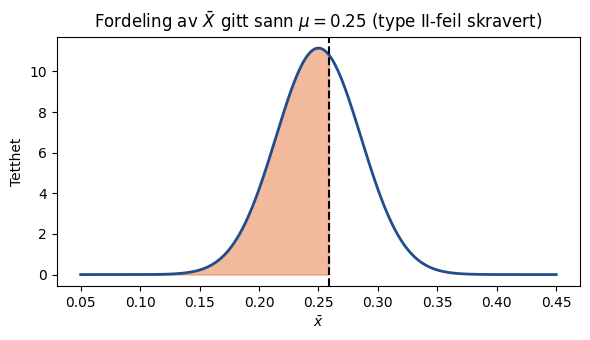

In [8]:
fig, ax = plt.subplots()
x = np.linspace(0.05, 0.45, 300)
ax.plot(x, stats.norm.pdf(x, mu_sann, SE), color="#1f4e8c", lw=2)
xr = np.linspace(0.05, k, 100)
ax.fill_between(xr, stats.norm.pdf(xr, mu_sann, SE), color="#E8743B", alpha=0.5)
ax.axvline(k, color="black", linestyle="--")
ax.set_xlabel(r"$\bar x$")
ax.set_ylabel("Tetthet")
ax.set_title(f"Fordeling av $\\bar X$ gitt sann $\\mu=0.25$ (type II-feil skravert)")
plt.tight_layout()
plt.show()

**Tolkning:** Dette er prisen vi betaler for at det skal være mindre enn $5\,\%$
sannsynlig å gjøre en type I-feil når $\mu=0.2$.

### 3c) Samme oppgave løst med $p$-verdi og Python

In [9]:
mu0, sigma, n = 0.2, 0.08, 5
SE = sigma / np.sqrt(n)

for xbar_obs in [0.25, 0.30]:
    T_obs = (xbar_obs - mu0) / SE
    p_verdi = stats.norm.sf(T_obs)
    beslutning = "forkast H0" if p_verdi < 0.05 else "behold H0"
    print(f"xbar={xbar_obs}: T_obs={T_obs:.3f}, p={p_verdi:.4f}  -> {beslutning}")

xbar=0.25: T_obs=1.398, p=0.0811  -> behold H0
xbar=0.3: T_obs=2.795, p=0.0026  -> forkast H0


**Konklusjon:** $\bar x=0.25 \Rightarrow p=0.081>0.05$ (går fri).
$\bar x=0.30 \Rightarrow p=0.003<0.05$ (dømmes) --- samme konklusjon som med kritisk verdi,
siden de to metodene alltid er ekvivalente.

### 3d) Samme eksempel, men med $t$-fordeling ($\sigma$ ukjent)

Til nå har vi antatt at $\sigma=0.08$ er *kjent* (oppgitt av produsenten), og brukt
$Z$-fordelingen. Men hva om vi i stedet må *estimere* $\sigma$ fra selve målingene?
Da bruker vi $S$ i stedet for $\sigma$, og $t$-fordelingen med $n-1$ frihetsgrader
i stedet for $Z$.

**Data:** Alkometeret gir $n=5$ målinger: $0.24, 0.27, 0.23, 0.26, 0.25$.

In [2]:
malinger = np.array([0.24, 0.27, 0.23, 0.26, 0.25])
n = len(malinger)
xbar = malinger.mean()
S = malinger.std(ddof=1)
SE = S / np.sqrt(n)
df = n - 1

print(f"xbar = {xbar:.4f}")
print(f"S    = {S:.4f}")
print(f"SE   = {SE:.4f}")
print(f"df   = {df}")

xbar = 0.2500
S    = 0.0158
SE   = 0.0071
df   = 4


In [8]:
x_m = [0.24, 0.27, 0.23, 0.26, 0.25]
#ss_l = [(0.24 -0.25)**2,(0.27-0.25)**2,... ]
ss_l = [(i - 0.25)**2 for i in x_m]
s_2 = sum(ss_l)/(n-1)
s_2
std_s = np.sqrt(s_2)
SE1 = std_s/np.sqrt(5)
SE1

np.float64(0.007071067811865478)

In [10]:
mu0 = 0.2
T_obs = (xbar - mu0) / SE

# p-verdi med t-fordelingens CDF (ensidig test, H1: mu > mu0)
p_verdi_cdf = 1 - stats.t.cdf(T_obs, df=df)

# samme resultat med stats.t.sf (survival function = 1 - cdf, mer numerisk stabil)
p_verdi_sf = stats.t.sf(T_obs, df=df)

print(f"T_obs = {T_obs:.4f}")
print(f"p-verdi (via 1 - t.cdf)  = {p_verdi_cdf:.6f}")
print(f"p-verdi (via t.sf)       = {p_verdi_sf:.6f}")

T_obs = 7.0711
p-verdi (via 1 - t.cdf)  = 0.001055
p-verdi (via t.sf)       = 0.001055


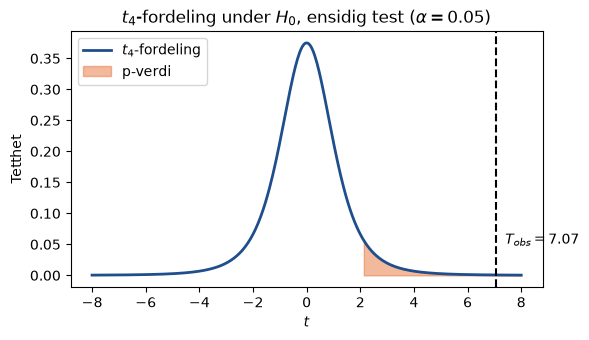

p = 0.001055 < 0.05  ->  forkast H0


In [11]:
fig, ax = plt.subplots()
x = np.linspace(-8, 8, 400)
ax.plot(x, stats.t.pdf(x, df), color="#1f4e8c", lw=2, label=f"$t_{{{df}}}$-fordeling")
t_krit = stats.t.ppf(0.95, df)
xr = np.linspace(t_krit, 8, 100)
ax.fill_between(xr, stats.t.pdf(xr, df), color="#E8743B", alpha=0.5, label="p-verdi")
ax.axvline(T_obs, color="black", linestyle="--")
ax.text(T_obs, 0.05, f"  $T_{{obs}}={T_obs:.2f}$", fontsize=10)
ax.set_xlabel("$t$")
ax.set_ylabel("Tetthet")
ax.set_title(f"$t_{{{df}}}$-fordeling under $H_0$, ensidig test ($\\alpha=0.05$)")
ax.legend()
plt.tight_layout()
plt.show()

beslutning = "forkast H0" if p_verdi_sf < 0.05 else "behold H0"
print(f"p = {p_verdi_sf:.6f} < 0.05  ->  {beslutning}")

**Konklusjon:** Med $\sigma$ ukjent bruker vi $t_4$-fordelingen i stedet for $Z$.
$T_{obs}\approx7.07$ er ekstremt langt ute i høyre hale av $t_4$-fordelingen, og
$p\approx0.0011<0.05$ $\Rightarrow$ **forkast $H_0$**: sjåføren dømmes --- her enda
tydeligere enn i $Z$-eksemplene over, siden gjennomsnittet ligger godt over grensen
og spredningen mellom målingene er liten.

Legg merke til at `1 - stats.t.cdf(T_obs, df)` og `stats.t.sf(T_obs, df)` gir
(tilnærmet) identisk resultat --- `sf` (*survival function*) er bare en mer numerisk
stabil måte å regne ut $1-F(t)$ på, og er å foretrekke når $p$-verdien er veldig liten.

---
## 4. Konfidensintervall og hypotesetest for én andel

**Oppgave:** Med dagens (gamle) produksjonsutstyr må $11\,\%$ av enhetene vrakes.
Et nytt utstyr testes med en prøveproduksjon på $n=160$ enheter, hvorav $13$ må vrakes.
Er det nye utstyret bedre?

In [13]:
n, x = 160, 13
p_hat = x / n
print(f"phat = {x}/{n} = {p_hat:.4f} = {p_hat*100:.1f}%")

z = stats.norm.ppf(0.975)
print('z_0.05: ',z)
SE = np.sqrt(p_hat * (1 - p_hat) / n)
ki = (p_hat - z*SE, p_hat + z*SE)
print(f"95% KI for vraksannsynligheten: [{ki[0]*100:.1f}%, {ki[1]*100:.1f}%]")

p_gammel = 0.11
print(f"\nDagens vraksannsynlighet ({p_gammel*100:.0f}%) "
      f"{'ligger i' if ki[0] <= p_gammel <= ki[1] else 'ligger UTENFOR'} intervallet.")

phat = 13/160 = 0.0813 = 8.1%
z_0.05:  1.959963984540054
95% KI for vraksannsynligheten: [3.9%, 12.4%]

Dagens vraksannsynlighet (11%) ligger i intervallet.


**Konklusjon:** $95\,\%$ KI $\approx[3.9\,\%,\ 12.3\,\%]$. Dagens vraksannsynlighet
($11\,\%$) ligger innenfor dette intervallet --- vi kan derfor **ikke** konkludere sikkert
at det nye utstyret er bedre.

### Intervallengde og nødvendig utvalgsstørrelse

In [14]:
z = stats.norm.ppf(0.975)
L = 0.02  # onsket bredde

# Med utgangspunkt i phat = 0.081
n_behov = 4 * p_hat * (1 - p_hat) * (z / L)**2
print(f"n for L={L} med phat={p_hat:.3f}: n = {n_behov:.0f}")

# Worst case: phat = 0.5
n_worst = (z / L)**2
print(f"Worst case (phat=0.5): n = {n_worst:.0f}")

n for L=0.02 med phat=0.081: n = 2868
Worst case (phat=0.5): n = 9604


---
## 5. Effektstørrelse

### Cohens $d$ (ett gjennomsnitt)

$$ d = \frac{\bar x - \mu_0}{s} $$

In [15]:
def cohens_d_one_sample(xbar, mu0, s):
    return (xbar - mu0) / s

# Eksempel med produksjonstid-dataene (mu0 = 40 til illustrasjon)
d = cohens_d_one_sample(mu_hat, mu0=38, s=sigma_hat)
print(f"Cohens d = {d:.3f}")
print("Tommelfingerregler: |d|=0.2 liten, 0.5 middels, 0.8 stor")

Cohens d = 0.686
Tommelfingerregler: |d|=0.2 liten, 0.5 middels, 0.8 stor


### Cohens $h$ (én andel)

$$ h = 2\arcsin(\sqrt{\hat p}) - 2\arcsin(\sqrt{p_0}) $$

In [16]:
def cohens_h(p1, p0):
    return 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p0))

# Eksempel: vraksannsynlighet 8.1% mot gammel andel 11%
h = cohens_h(p_hat, 0.11)
print(f"Cohens h = {h:.3f}  (liten effekt)")

Cohens h = -0.098  (liten effekt)


---
## 6. Bootstrap-eksempel med høydedata

Datasett: $n=100$ høyder (cm), $\bar x=175.35$, $s=10.00$ (samme data som i kap. 13.5.1
i hovedforelesningen).

In [14]:
heights = np.array([
    154, 157, 158, 159, 160, 161, 161, 161, 161, 162, 162, 162, 162, 162,
    164, 165, 166, 166, 166, 166, 167, 167, 168, 168, 168, 168, 169, 169,
    170, 170, 170, 170, 171, 171, 171, 172, 173, 173, 173, 173, 173, 173,
    173, 173, 173, 173, 173, 174, 175, 175, 175, 175, 176, 176, 177, 177,
    177, 177, 178, 178, 178, 178, 178, 178, 178, 179, 179, 179, 179, 179,
    179, 180, 180, 181, 181, 181, 181, 181, 182, 184, 185, 185, 185, 186,
    186, 187, 187, 188, 188, 189, 189, 190, 190, 191, 191, 192, 194, 197,
    199, 204
])
n = len(heights)
xbar = heights.mean()
s = heights.std(ddof=1)
print(f"n={n}, xbar={xbar:.2f}, s={s:.2f}")

n=100, xbar=175.35, s=10.00


In [23]:
B = 10_000
rng = np.random.default_rng(200)

bootstrap_means = np.empty(B)
for b in range(B):
    resample = rng.choice(heights, size=n, replace=True)
    bootstrap_means[b] = resample.mean()

ki_boot = np.percentile(bootstrap_means, [2.5, 97.5])

# klassisk t-KI til sammenligning
df = n - 1
t_star = stats.t.ppf(0.975, df)
se_classic = s / np.sqrt(n)
ki_classic = (xbar - t_star*se_classic, xbar + t_star*se_classic)

print(f"Bootstrap 95% KI: [{ki_boot[0]:.3f}, {ki_boot[1]:.3f}]")
print(f"Klassisk (t) 95% KI: [{ki_classic[0]:.3f}, {ki_classic[1]:.3f}]")

Bootstrap 95% KI: [173.450, 177.280]
Klassisk (t) 95% KI: [173.365, 177.335]


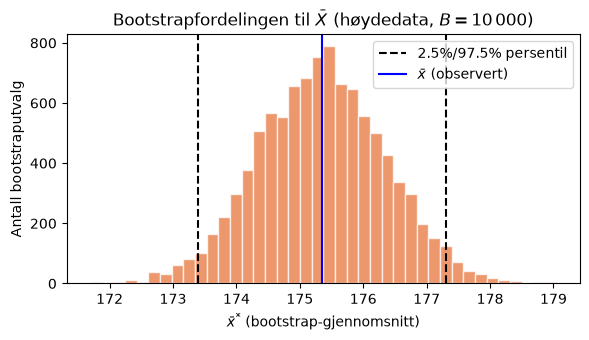

In [20]:
fig, ax = plt.subplots()
ax.hist(bootstrap_means, bins=40, color="#E8743B", alpha=0.75, edgecolor="white")
ax.axvline(ki_boot[0], color="black", linestyle="--", label="2.5%/97.5% persentil")
ax.axvline(ki_boot[1], color="black", linestyle="--")
ax.axvline(xbar, color="blue", label=r"$\bar x$ (observert)")
ax.set_xlabel(r"$\bar x^{*}$ (bootstrap-gjennomsnitt)")
ax.set_ylabel("Antall bootstraputvalg")
ax.set_title("Bootstrapfordelingen til $\\bar X$ (høydedata, $B=10\\,000$)")
ax.legend()
plt.tight_layout()
plt.show()

**Resultat:** Bootstrap-KI og det klassiske $t$-KI er nesten identiske --- dette
bekrefter hverandre siden $n=100$ er stort nok til at sentralgrenseteoremet fungerer godt.